# LOCA severity analysis

This notebook loads LOCA/1.csv through LOCA/100.csv with reusable code from `src/data_loader.py`.

NPPAD's README defines the LOCA case number as the severity setting: `1` is 1% of a 100 cm² break, so `severity` below is the numeric percentage of a 100 cm² break. The early-warning screen deliberately excludes WLR, WBK, and MBK from its composite.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'src' / 'data_loader.py').exists()
)
sys.path.insert(0, str(project_root / 'src'))

from data_loader import (
    DIRECT_ACCIDENT_FEATURES,
    EARLY_WARNING_FEATURES,
    build_loca_summary,
    load_loca_dataset,
    validate_loca_files,
)

print('Project:', project_root)

Project: C:\Users\18205\NPP-Guard


## 1. File, schema, and time-axis validation

In [2]:
validation = validate_loca_files()
display(validation.head())

print('Files:', len(validation))
print('Missing files:', int((~validation['exists']).sum()))
print('Column sets identical:', bool(validation['column_match'].all()))
print('Missing cells:', int(validation['missing_cells'].sum()))
print('Strictly increasing TIME:', bool(validation['time_strictly_increasing'].all()))
print('10-second grid consistent:', bool(validation['time_grid_10s'].all()))
print('TIME end range:', validation['time_end_s'].min(), 'to', validation['time_end_s'].max(), 's')
print('Interpretation: start and sampling interval are consistent; simulation end times vary by case.')

issues = validation[
    (~validation['exists'])
    | validation['error'].notna()
    | (~validation['column_match'])
    | (~validation['time_grid_10s'])
    | (validation['missing_cells'] > 0)
]
display(issues if len(issues) else pd.DataFrame({'status': ['No file-level anomalies found']}))

,sample_id,severity,severity_unit,file,exists,error,rows,columns,missing_cells,missing_columns,column_match,time_numeric,time_strictly_increasing,time_duplicate_count,time_start_s,time_end_s,time_step_s,time_step_min_s,time_step_max_s,time_grid_10s
0,LOCA_001,1,% of 100 cm2 break area,1.csv,True,None,475,97,0,0,True,True,True,0,0.0,4740.0,10.0,10.0,10.0,True
1,LOCA_002,2,% of 100 cm2 break area,2.csv,True,None,471,97,0,0,True,True,True,0,0.0,4700.0,10.0,10.0,10.0,True
2,LOCA_003,3,% of 100 cm2 break area,3.csv,True,None,458,97,0,0,True,True,True,0,0.0,4570.0,10.0,10.0,10.0,True
3,LOCA_004,4,% of 100 cm2 break area,4.csv,True,None,452,97,0,0,True,True,True,0,0.0,4510.0,10.0,10.0,10.0,True
4,LOCA_005,5,% of 100 cm2 break area,5.csv,True,None,449,97,0,0,True,True,True,0,0.0,4480.0,10.0,10.0,10.0,True


Files: 100
Missing files: 0
Column sets identical: True
Missing cells: 0
Strictly increasing TIME: True
10-second grid consistent: True
TIME end range: 3010.0 to 4740.0 s
Interpretation: start and sampling interval are consistent; simulation end times vary by case.


,status
0,No file-level anomalies found


## 2. Batch-loaded analysis dataset

In [3]:
loca = load_loca_dataset()
print('Shape including metadata:', loca.shape)
print('Samples:', loca['sample_id'].nunique())
print('Severity range:', loca['severity'].min(), 'to', loca['severity'].max())

missing_by_column = loca.isna().sum().sort_values(ascending=False)
display(missing_by_column[missing_by_column > 0].to_frame('missing_cells'))
display(loca.groupby('severity', as_index=False).size().head())

Shape including metadata: (39017, 102)
Samples: 100
Severity range: 1 to 100


,missing_cells


,severity,size
0,1,475
1,2,471
2,3,458
3,4,452
4,5,449


## 3. Representative process-variable trajectories

The following plots show requested process variables for six severity levels. WLR/WBK/MBK are not used as the sole evidence; the next sections quantify non-direct process deviations against `Normal/1.csv`.

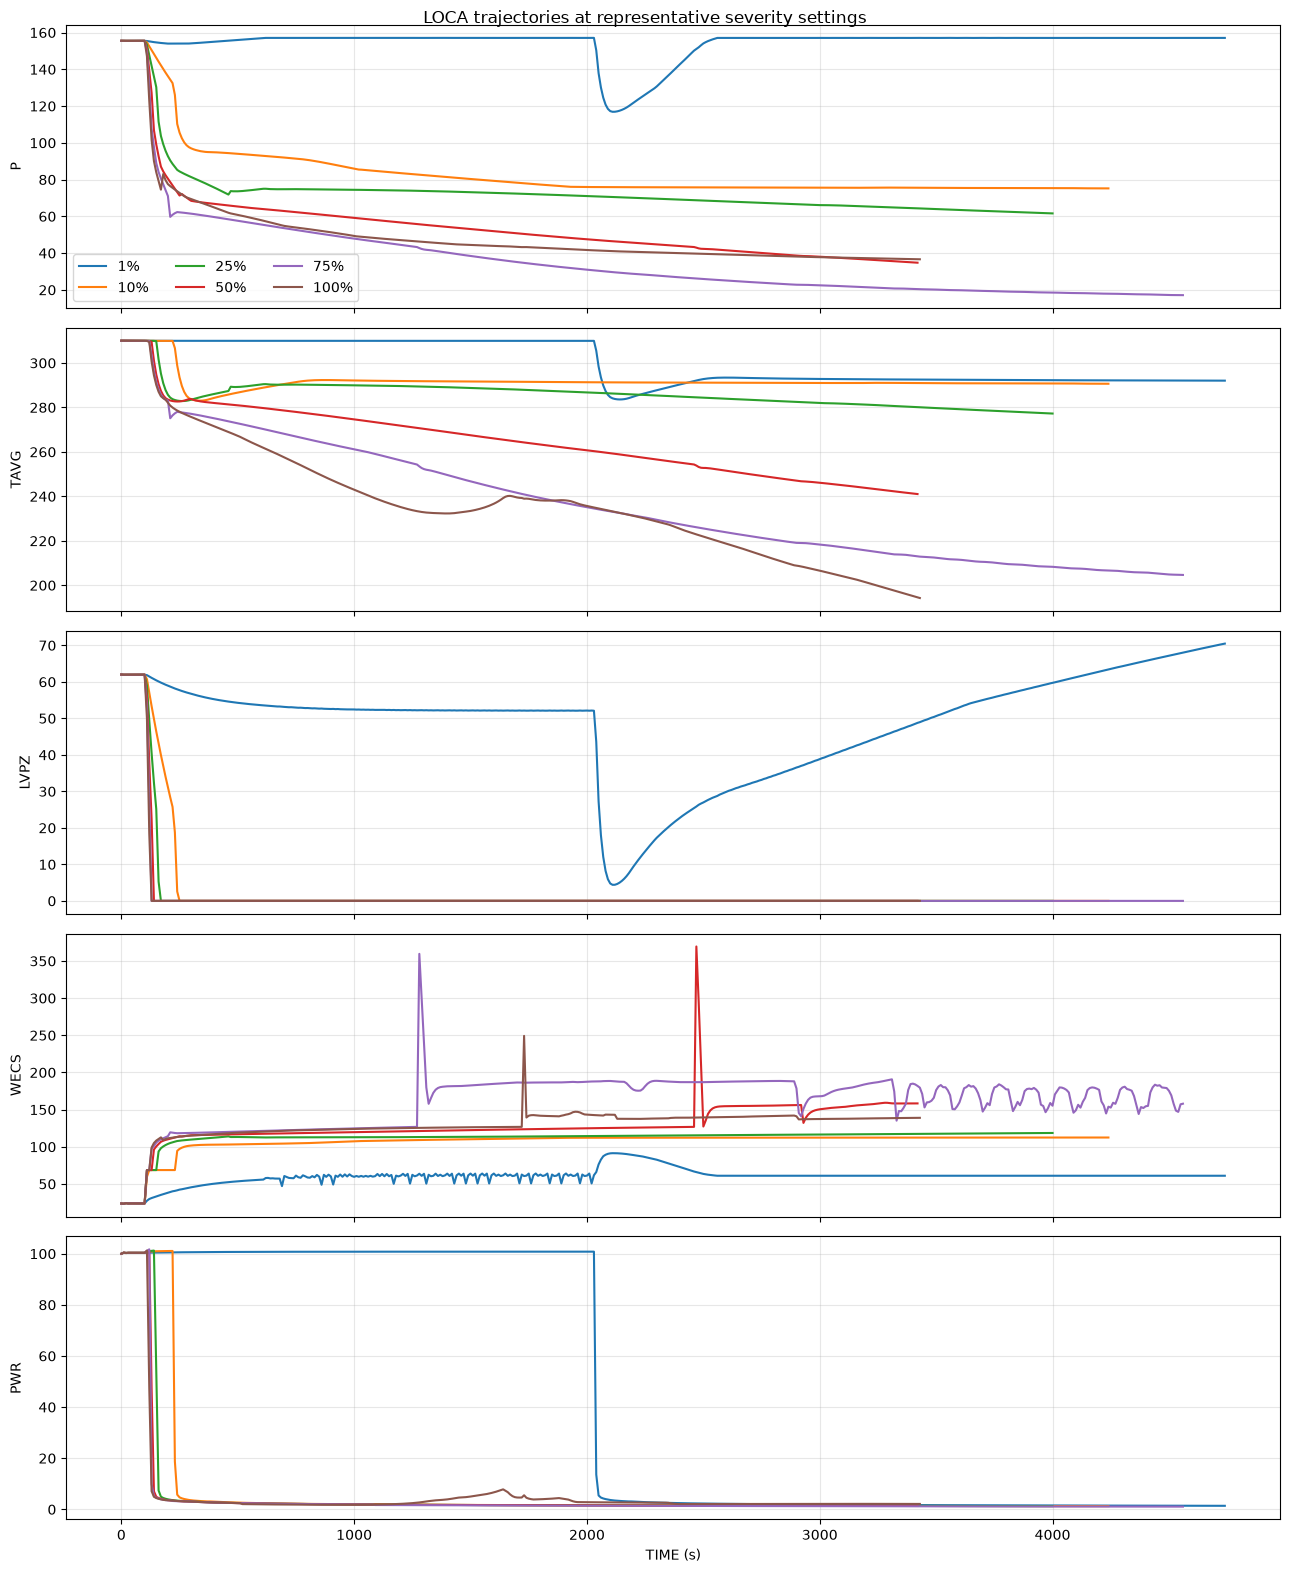

In [4]:
representative_severities = [1, 10, 25, 50, 75, 100]
plot_features = ['P', 'TAVG', 'LVPZ', 'WECS', 'PWR']
plot_data = loca[loca['severity'].isin(representative_severities)]

fig, axes = plt.subplots(len(plot_features), 1, figsize=(13, 16), sharex=True)
for axis, feature in zip(axes, plot_features):
    for severity, group in plot_data.groupby('severity'):
        axis.plot(group['TIME'], group[feature], label=f'{severity}%')
    axis.set_ylabel(feature)
    axis.grid(alpha=0.3)
axes[0].legend(ncol=3)
axes[-1].set_xlabel('TIME (s)')
fig.suptitle('LOCA trajectories at representative severity settings')
plt.tight_layout()
plt.show()

## 4. Non-direct early-warning screen

For each case, each feature is compared with the same-time value in `Normal/1.csv`. The scale is estimated from normal `TIME <= 100 s` using `max(std, 1% of median absolute value)`. A feature is marked as deviating at the first time its score exceeds 3 for three consecutive samples (30 s). The composite is the median over the following non-direct process/protection signals.

In [5]:
summary = build_loca_summary()
summary_path = project_root / 'results' / 'loca_severity_summary.csv'
summary.to_csv(summary_path, index=False)

first_columns = [
    'sample_id', 'severity',
    *[f'{feature}_first_deviation_s' for feature in ['P', 'TAVG', 'LVPZ', 'WECS', 'PWR']],
    'indirect_composite_first_deviation_s',
    'hpi_pump_start_s', 'scram_s', 'whpi_first_positive_s',
    'lead_time_to_hpi_s', 'lead_time_to_scram_s',
]
display(summary[first_columns].head(10))
print('Excluded direct accident channels:', DIRECT_ACCIDENT_FEATURES)
print('Saved:', summary_path)

,sample_id,severity,P_first_deviation_s,TAVG_first_deviation_s,LVPZ_first_deviation_s,WECS_first_deviation_s,PWR_first_deviation_s,indirect_composite_first_deviation_s,hpi_pump_start_s,scram_s,whpi_first_positive_s,lead_time_to_hpi_s,lead_time_to_scram_s
0,LOCA_001,1,60.0,100.0,30.0,20.0,30.0,40.0,2031.5,2032.5,2040.0,1991.5,1992.5
1,LOCA_002,2,120.0,100.0,50.0,20.0,30.0,40.0,1094.5,1095.5,1100.0,1054.5,1055.5
2,LOCA_003,3,70.0,100.0,30.0,20.0,30.0,30.0,790.5,791.5,800.0,760.5,761.5
3,LOCA_004,4,40.0,70.0,30.0,20.0,30.0,30.0,577.0,569.0,580.0,547.0,539.0
4,LOCA_005,5,30.0,60.0,30.0,20.0,30.0,30.0,427.0,417.5,430.0,397.0,387.5
5,LOCA_006,6,30.0,50.0,30.0,20.0,30.0,30.0,350.5,340.0,360.0,320.5,310.0
6,LOCA_007,7,30.0,50.0,30.0,20.0,30.0,30.0,304.5,293.5,310.0,274.5,263.5
7,LOCA_008,8,30.0,40.0,30.0,20.0,30.0,30.0,274.0,262.5,280.0,244.0,232.5
8,LOCA_009,9,30.0,40.0,30.0,20.0,30.0,30.0,252.0,240.5,260.0,222.0,210.5
9,LOCA_010,10,30.0,40.0,30.0,20.0,30.0,30.0,235.5,224.0,240.0,205.5,194.0


Excluded direct accident channels: ('WLR', 'WBK', 'MBK')
Saved: C:\Users\18205\NPP-Guard\results\loca_severity_summary.csv


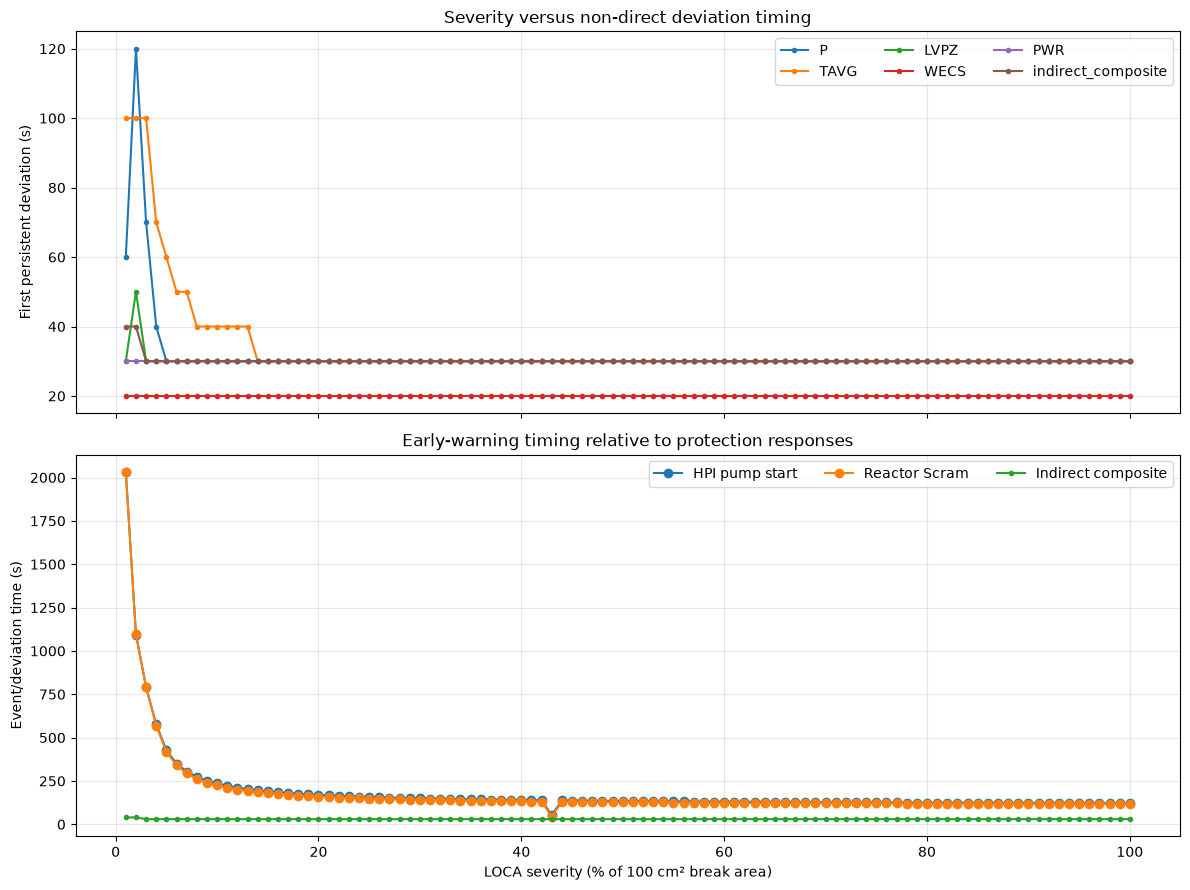

In [6]:
timing_features = ['P', 'TAVG', 'LVPZ', 'WECS', 'PWR', 'indirect_composite']
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for feature in timing_features:
    column = f'{feature}_first_deviation_s'
    axes[0].plot(summary['severity'], summary[column], marker='.', label=feature)
axes[0].set_ylabel('First persistent deviation (s)')
axes[0].set_title('Severity versus non-direct deviation timing')
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].plot(summary['severity'], summary['hpi_pump_start_s'], marker='o', label='HPI pump start')
axes[1].plot(summary['severity'], summary['scram_s'], marker='o', label='Reactor Scram')
axes[1].plot(summary['severity'], summary['indirect_composite_first_deviation_s'], marker='.', label='Indirect composite')
axes[1].set_xlabel('LOCA severity (% of 100 cm² break area)')
axes[1].set_ylabel('Event/deviation time (s)')
axes[1].set_title('Early-warning timing relative to protection responses')
axes[1].grid(alpha=0.3)
axes[1].legend(ncol=3)
plt.tight_layout()
plt.show()

## 5. Initial findings

In [7]:
timing_columns = [f'{feature}_first_deviation_s' for feature in EARLY_WARNING_FEATURES]
median_timing = summary[timing_columns].median().sort_values()
display(median_timing.rename_axis('feature').to_frame('median_first_deviation_s'))

print('Median composite first deviation (s):', summary['indirect_composite_first_deviation_s'].median())
print('Median HPI pump start (s):', summary['hpi_pump_start_s'].median())
print('Cases with composite deviation before HPI:', int((summary['lead_time_to_hpi_s'] > 0).sum()), '/', len(summary))
print('Median lead time to HPI (s):', summary['lead_time_to_hpi_s'].median())
print('Median lead time to Scram (s):', summary['lead_time_to_scram_s'].median())
print('Severity/time correlation is descriptive only; it is not a causal or safety claim.')

,median_first_deviation_s
feature,
WECS_first_deviation_s,20.0
P_first_deviation_s,30.0
TAVG_first_deviation_s,30.0
LVPZ_first_deviation_s,30.0
PWR_first_deviation_s,30.0
SCMA_first_deviation_s,30.0
TRB_first_deviation_s,30.0
PRB_first_deviation_s,30.0
LWRB_first_deviation_s,30.0


Median composite first deviation (s): 30.0
Median HPI pump start (s): 133.75
Cases with composite deviation before HPI: 100 / 100
Median lead time to HPI (s): 103.75
Median lead time to Scram (s): 96.75
Severity/time correlation is descriptive only; it is not a causal or safety claim.


In [8]:
assert len(validation) == 100
assert validation['exists'].all()
assert validation['column_match'].all()
assert validation['missing_cells'].sum() == 0
assert validation['time_grid_10s'].all()
assert loca['sample_id'].nunique() == 100
assert summary['severity'].tolist() == list(range(1, 101))
assert set(summary['hpi_pump_start_s'].notna()) == {True}
print('All notebook validation assertions passed.')

All notebook validation assertions passed.
